# 03 · LeWM on real PushT data

> A full walkthrough on the real expert dataset and a real GPU. Every number and every figure on this page is computed live — nothing is illustrative.

This notebook is **not** exported to a `.py` file. It is the tutorial.

### What you will see

1. Real PushT frames from the 46 GB expert dataset
2. The pretrained model's latent space, and the structure hiding in it
3. `SIGReg` measured directly against the Gaussian it is chasing
4. Optionally, **a model trained from scratch**, escaping collapse in ~5 minutes
5. The world model imagining the future, and its error growing with horizon
6. Planning: scoring candidate action plans by imagined outcome

### What you need

- The dataset at `$STABLEWM_HOME/pusht_expert_train.h5` (see README)
- The pretrained checkpoint at `$STABLEWM_HOME/hf_pusht/`
- A CUDA GPU with ~6 GB free for the optional training section

`RUN_TRAINING` is `False` by default. Run the whole notebook first in that safe mode; section 5 explains how to opt in to the five-minute training experiment.

In [1]:
import json
import math
import os
import pathlib
import sys
import time
from typing import Any

# The notebooks live in nbs/, so put the repo root on sys.path.
_root = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "nbs" else pathlib.Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import hdf5plugin  # noqa: F401 -- registers the Blosc filter used by the .h5
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

import stable_pretraining as spt
from lewm.jepa import JEPA
from lewm.module import ARPredictor, Embedder, MLP, SIGReg

plt.rcParams.update({
    "figure.facecolor": "white", "axes.grid": True,
    "grid.alpha": 0.3, "font.size": 10,
})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Same resolution order stable_worldmodel uses: $STABLEWM_HOME, else the default.
HOME = pathlib.Path(os.environ.get("STABLEWM_HOME", pathlib.Path.home() / ".stable_worldmodel"))
H5 = HOME / "pusht_expert_train.h5"
CKPT = HOME / "hf_pusht"

torch.manual_seed(0)
np.random.seed(0)

print(f"device      {DEVICE}")
if DEVICE == "cuda":
    print(f"gpu         {torch.cuda.get_device_name(0)}")
print(f"dataset     {H5}  ({H5.stat().st_size/1e9:.1f} GB)" if H5.exists() else f"MISSING {H5}")
print(f"checkpoint  {CKPT}" if CKPT.exists() else f"MISSING {CKPT}")

device      cuda
gpu         NVIDIA GeForce RTX 4070 SUPER
dataset     /home/gilozoaire/.stable_worldmodel/pusht_expert_train.h5  (46.3 GB)
checkpoint  /home/gilozoaire/.stable_worldmodel/hf_pusht


## 1 · The data

PushT: push a grey T-shaped block onto a green target outline. The blue dot is
the pusher, the only thing you control.

The dataset is stored flat — 2.3M frames in one long array — with `ep_offset`
and `ep_len` marking where each episode begins and how long it runs.

In [2]:
with h5py.File(H5, "r") as f:
    print("columns:")
    for k in f.keys():
        d = f[k]
        print(f"  {k:12s} {str(d.shape):26s} {d.dtype}")

    ep_offset = f["ep_offset"][:]
    ep_len = f["ep_len"][:]

print(f"\n{len(ep_len):,} episodes, {ep_len.sum():,} frames")
print(f"episode length: min {ep_len.min()}, median {int(np.median(ep_len))}, max {ep_len.max()}")

columns:
  action       (2336736, 2)               float32
  ep_len       (18685,)                   int32
  ep_offset    (18685,)                   int64
  episode_idx  (2336736,)                 int64
  pixels       (2336736, 224, 224, 3)     uint8
  proprio      (2336736, 4)               float32
  state        (2336736, 7)               float32
  step_idx     (2336736,)                 int64

18,685 episodes, 2,336,736 frames
episode length: min 49, median 123, max 246


### What an episode looks like

Twelve frames spread across one expert demonstration. Watch the T-block travel
into the green target.

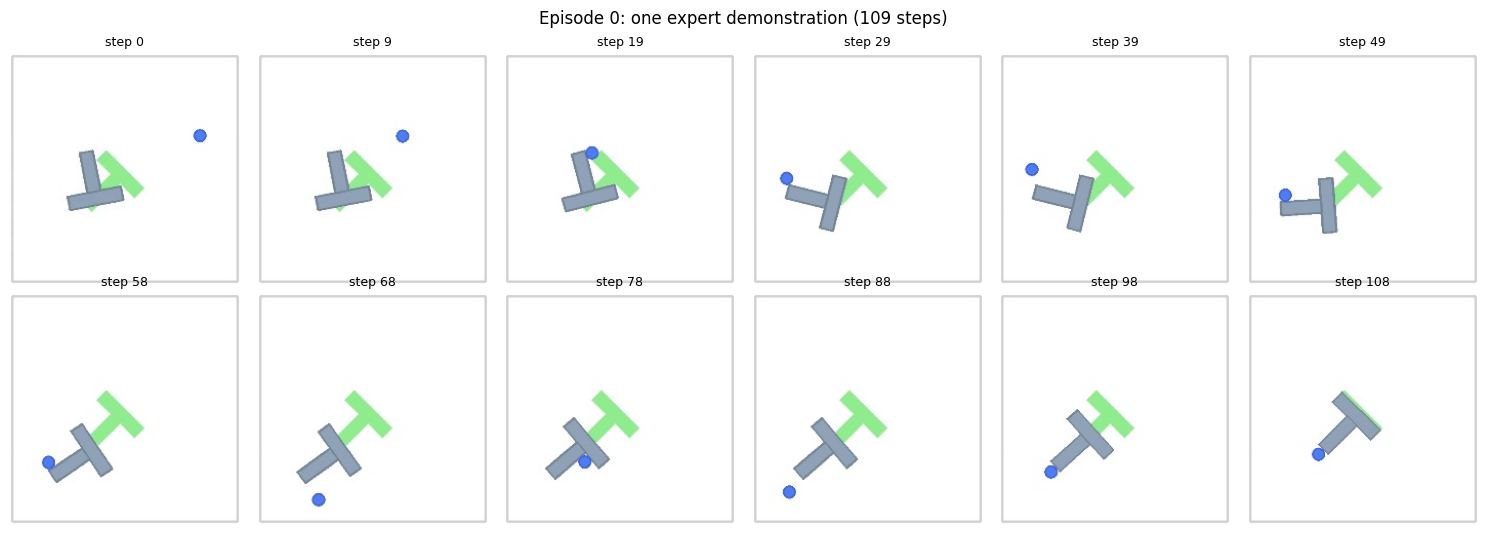

In [3]:
EP = 0
o, n = int(ep_offset[EP]), int(ep_len[EP])
idx = np.linspace(o, o + n - 1, 12).astype(int)

with h5py.File(H5, "r") as f:
    strip = f["pixels"][idx]                 # (12, 224, 224, 3)
    strip_actions = f["action"][idx]

fig, axes = plt.subplots(2, 6, figsize=(15, 5.4))
for i, ax in enumerate(axes.flat):
    ax.imshow(strip[i])
    ax.set_title(f"step {idx[i] - o}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"Episode {EP}: one expert demonstration ({n} steps)", fontsize=12)
plt.tight_layout()
plt.show()

The grey T starts away from the green outline and ends on it. That is the task,
and the whole dataset is 18,685 variations of it.

### The other columns

`pixels` is what the model sees. The rest is what the simulator knows.

In [4]:
with h5py.File(H5, "r") as f:
    a = f["action"][o : o + 6]
    p = f["proprio"][o : o + 6]
    s = f["state"][o : o + 6]

print("action  (2)  -- the pusher's movement command")
print(a, "\n")
print("proprio (4)  -- pusher x, y, and velocity")
print(p.round(1), "\n")
print("state   (7)  -- full simulator state: pusher + T-block pose")
print(s.round(1))
print("\nThe model is trained on pixels and actions only.")
print("proprio and state are used for evaluation probes, never as model input.")

action  (2)  -- the pusher's movement command
[[ 0.14       -0.25      ]
 [ 0.05860596 -0.086082  ]
 [-0.02440063  0.03736725]
 [-0.10364655  0.0457756 ]
 [-0.51022613 -0.04200561]
 [-0.4677777   0.0153157 ]] 

proprio (4)  -- pusher x, y, and velocity
[[ 423.   182.     0.     0. ]
 [ 427.1  174.6   52.4  -93.5]
 [ 430.4  169.3   21.6  -31.6]
 [ 430.4  169.4   -9.3   14.2]
 [ 427.   171.2  -38.7   17. ]
 [ 410.8  170.5 -190.6  -15.8]] 

state   (7)  -- full simulator state: pusher + T-block pose
[[ 423.   182.   192.7  335.2    2.9    0.     0. ]
 [ 427.1  174.6  192.7  335.2    2.9   52.4  -93.5]
 [ 430.4  169.3  192.7  335.2    2.9   21.6  -31.6]
 [ 430.4  169.4  192.7  335.2    2.9   -9.3   14.2]
 [ 427.   171.2  192.7  335.2    2.9  -38.7   17. ]
 [ 410.8  170.5  192.7  335.2    2.9 -190.6  -15.8]]

The model is trained on pixels and actions only.
proprio and state are used for evaluation probes, never as model input.


### Frameskip: what one "step" means

The config uses `frameskip: 5`. One model timestep spans 5 simulator frames,
and the action for that step is the **5 raw actions stacked into one 10-vector**.
That is why `action_encoder.input_dim` is 10 rather than 2.

Effect: the model sees larger, more meaningful changes per step instead of five
nearly identical frames.

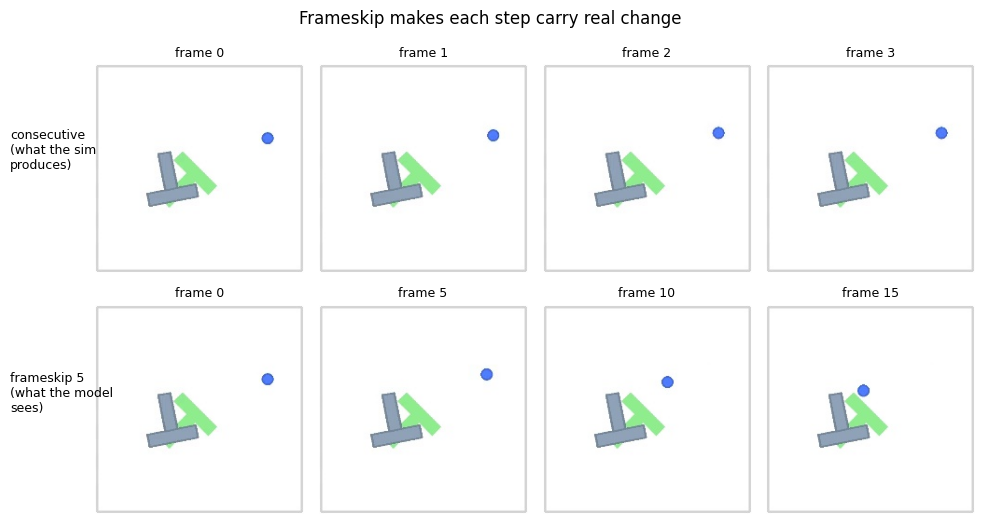

mean pixel change, consecutive frames : 0.30
mean pixel change, 5 frames apart    : 0.60   (2.0x more)


In [5]:
FRAMESKIP, HIST, NPRED = 5, 3, 1
SEQ = HIST + NPRED       # 4 timesteps per training sample

with h5py.File(H5, "r") as f:
    consecutive = f["pixels"][o : o + 4]
    skipped = f["pixels"][[o, o + 5, o + 10, o + 15]]

fig, axes = plt.subplots(2, 4, figsize=(10, 5.4))
for i in range(4):
    axes[0, i].imshow(consecutive[i]); axes[0, i].axis("off")
    axes[0, i].set_title(f"frame {i}", fontsize=9)
    axes[1, i].imshow(skipped[i]); axes[1, i].axis("off")
    axes[1, i].set_title(f"frame {i*5}", fontsize=9)
axes[0, 0].set_ylabel("raw")
fig.text(0.02, 0.72, "consecutive\n(what the sim\nproduces)", fontsize=9, va="center")
fig.text(0.02, 0.27, f"frameskip {FRAMESKIP}\n(what the model\nsees)", fontsize=9, va="center")
plt.suptitle("Frameskip makes each step carry real change", fontsize=12)
plt.tight_layout(rect=[0.09, 0, 1, 1])
plt.show()

d_raw = np.abs(consecutive[1].astype(int) - consecutive[0].astype(int)).mean()
d_skip = np.abs(skipped[1].astype(int) - skipped[0].astype(int)).mean()
print(f"mean pixel change, consecutive frames : {d_raw:.2f}")
print(f"mean pixel change, {FRAMESKIP} frames apart    : {d_skip:.2f}   ({d_skip/max(d_raw,1e-9):.1f}x more)")

## 2 · Loading the pretrained model

Two details the README's snippet omits, both of which will bite you:

1. **`config.json` contains `_target_` keys** for Hydra. They must be stripped
   before use as constructor kwargs.
2. **The checkpoint predates `transformers` v5.** The ViT's attention
   parameters were renamed (`attention.attention.query` → `attention.q_proj`,
   `intermediate.dense` → `mlp.fc1`, and so on). Loading without remapping
   silently leaves **192 encoder tensors randomly initialised** — the model
   still runs and still returns plausible shapes, which is exactly what makes
   it dangerous.

The remap below is mechanical: same tensors, new names.

In [6]:
import re

# transformers v4 -> v5 ViT parameter renaming.
_SUBS = [
    (r"^encoder\.encoder\.layer\.(\d+)\.attention\.attention\.query\.", r"encoder.layers.\1.attention.q_proj."),
    (r"^encoder\.encoder\.layer\.(\d+)\.attention\.attention\.key\.",   r"encoder.layers.\1.attention.k_proj."),
    (r"^encoder\.encoder\.layer\.(\d+)\.attention\.attention\.value\.", r"encoder.layers.\1.attention.v_proj."),
    (r"^encoder\.encoder\.layer\.(\d+)\.attention\.output\.dense\.",    r"encoder.layers.\1.attention.o_proj."),
    (r"^encoder\.encoder\.layer\.(\d+)\.intermediate\.dense\.",         r"encoder.layers.\1.mlp.fc1."),
    (r"^encoder\.encoder\.layer\.(\d+)\.output\.dense\.",               r"encoder.layers.\1.mlp.fc2."),
    (r"^encoder\.encoder\.layer\.(\d+)\.",                              r"encoder.layers.\1."),
]

def remap_state_dict(
    sd: dict[str, torch.Tensor],
) -> dict[str, torch.Tensor]:
    """Rename transformers-v4 ViT keys to their v5 equivalents."""
    out = {}
    for k, v in sd.items():
        for pat, rep in _SUBS:
            k2 = re.sub(pat, rep, k)
            if k2 != k:
                k = k2
                break
        out[k] = v
    return out


def build_model(cfg: dict[str, Any]) -> JEPA:
    """Construct the JEPA described by config.json (with _target_ stripped)."""
    strip = lambda d: {k: v for k, v in d.items() if k != "_target_"}
    encoder = spt.backbone.utils.vit_hf(
        cfg["encoder"]["size"],
        patch_size=cfg["encoder"]["patch_size"],
        image_size=cfg["encoder"]["image_size"],
        pretrained=False, use_mask_token=False,
    )
    head = lambda k: MLP(
        input_dim=cfg[k]["input_dim"], output_dim=cfg[k]["output_dim"],
        hidden_dim=cfg[k]["hidden_dim"], norm_fn=torch.nn.BatchNorm1d,
    )
    return JEPA(
        encoder=encoder,
        predictor=ARPredictor(**strip(cfg["predictor"])),
        action_encoder=Embedder(**strip(cfg["action_encoder"])),
        projector=head("projector"),
        pred_proj=head("pred_proj"),
    )


cfg = json.loads((CKPT / "config.json").read_text())
model = build_model(cfg)

raw_sd = torch.load(CKPT / "weights.pt", map_location="cpu", weights_only=False)

# Show what would happen without the remap.
miss_before, unexp_before = model.load_state_dict(raw_sd, strict=False)
print(f"without remap : {len(miss_before)} missing, {len(unexp_before)} unexpected  <-- silently broken")

model = build_model(cfg)
model.load_state_dict(remap_state_dict(raw_sd), strict=True)   # strict: no silent failures
print("with remap    : strict load OK, every tensor accounted for")

model = model.eval().to(DEVICE)
model.requires_grad_(False)
print(f"\nparameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

14:44:01 | INFO  | __init__.py | JAX version 0.6.2 available.
14:44:03 | INFO  | atomic_chec~| [atomic_save] installed crash-safe checkpoint plugin (write to sibling .tmp + fsync + atomic rename)
14:44:03 | INFO  | utils.py    | Created ViT-tiny from scratch with config: {'hidden_size': 192, 'num_hidden_layers': 12, 'num_attention_heads': 3, 'intermediate_size': 768, 'image_size': 224, 'patch_size': 14}
without remap : 192 missing, 192 unexpected  <-- silently broken
14:44:03 | INFO  | utils.py    | Created ViT-tiny from scratch with config: {'hidden_size': 192, 'num_hidden_layers': 12, 'num_attention_heads': 3, 'intermediate_size': 768, 'image_size': 224, 'patch_size': 14}
with remap    : strict load OK, every tensor accounted for

parameters: 18.0M


## 3 · Encoding real frames

The preprocessing has to match training: scale to `[0,1]`, normalise by the
ImageNet statistics, keep 224×224.

In [7]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3, 1, 1)


def to_model_input(
    px_uint8: np.ndarray | torch.Tensor, device: str = DEVICE
) -> torch.Tensor:
    """(..., H, W, 3) uint8  ->  (..., 3, H, W) normalised float on `device`."""
    x = torch.as_tensor(px_uint8)
    if x.ndim == 4:                       # (T, H, W, 3) -> add batch
        x = x.unsqueeze(0)
    x = x.permute(0, 1, 4, 2, 3).float() / 255.0
    return ((x - IMAGENET_MEAN) / IMAGENET_STD).to(device)


with h5py.File(H5, "r") as f:
    clip = f["pixels"][o : o + 8]

x = to_model_input(clip)
with torch.no_grad():
    emb = model.encode({"pixels": x})["emb"]

print(f"{tuple(clip.shape)} uint8 frames")
print(f"  -> {tuple(x.shape)} normalised input")
print(f"  -> {tuple(emb.shape)} embeddings")
print(f"\nEach 224x224x3 image ({224*224*3:,} numbers) becomes {emb.shape[-1]} numbers.")
print(f"Compression: {224*224*3/emb.shape[-1]:.0f}x")

(8, 224, 224, 3) uint8 frames
  -> (1, 8, 3, 224, 224) normalised input
  -> (1, 8, 192) embeddings

Each 224x224x3 image (150,528 numbers) becomes 192 numbers.
Compression: 784x


### Is the latent space meaningful?

A trained encoder should place consecutive frames close together (physics is
continuous) and unrelated episodes far apart. A collapsed encoder would put
*everything* in the same place, and a broken one would show no pattern at all.

Cosine similarity between embeddings answers this directly.

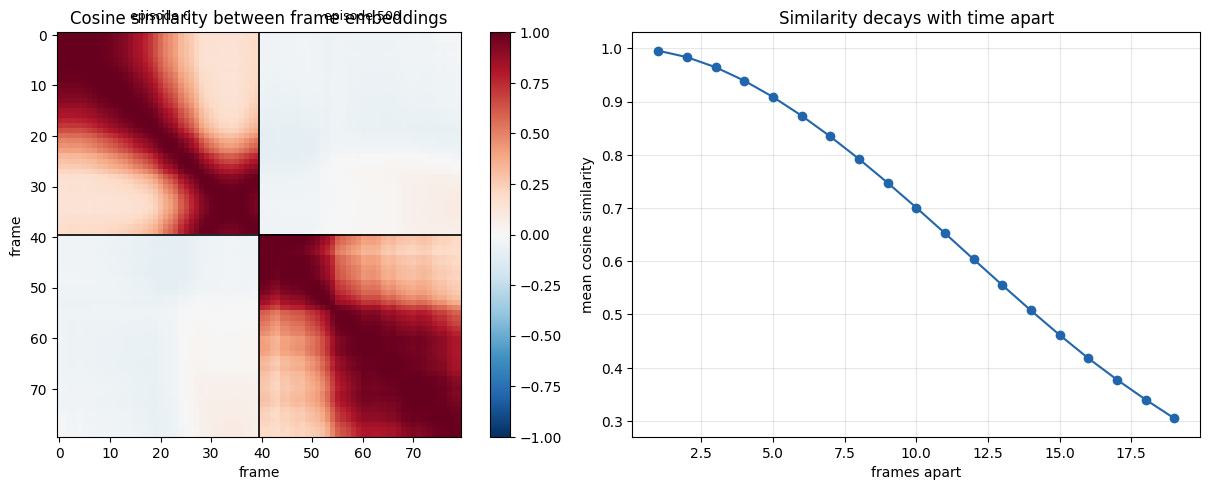

consecutive frames, same episode : +0.9956
frames from different episodes   : -0.0304
per-dimension std                : 0.7774   (collapse would be ~0)


In [8]:
N_FRAMES = 40
with h5py.File(H5, "r") as f:
    ep_a = f["pixels"][int(ep_offset[0]) : int(ep_offset[0]) + N_FRAMES]
    ep_b = f["pixels"][int(ep_offset[500]) : int(ep_offset[500]) + N_FRAMES]

with torch.no_grad():
    emb_a = model.encode({"pixels": to_model_input(ep_a)})["emb"][0]
    emb_b = model.encode({"pixels": to_model_input(ep_b)})["emb"][0]

both = torch.cat([emb_a, emb_b])
unit = torch.nn.functional.normalize(both, dim=-1)
sim = (unit @ unit.T).cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

im = ax1.imshow(sim, cmap="RdBu_r", vmin=-1, vmax=1)
ax1.axhline(N_FRAMES - 0.5, color="k", lw=1.2)
ax1.axvline(N_FRAMES - 0.5, color="k", lw=1.2)
ax1.set_title("Cosine similarity between frame embeddings")
ax1.set_xlabel("frame"); ax1.set_ylabel("frame")
ax1.text(N_FRAMES/2, -3, "episode 0", ha="center", fontsize=9)
ax1.text(N_FRAMES*1.5, -3, "episode 500", ha="center", fontsize=9)
ax1.grid(False)
plt.colorbar(im, ax=ax1, fraction=0.046)

offsets = range(1, 20)
curve = [float(torch.nn.functional.cosine_similarity(emb_a[:-k], emb_a[k:], dim=-1).mean())
         for k in offsets]
ax2.plot(list(offsets), curve, "o-", color="#2166ac")
ax2.set_xlabel("frames apart"); ax2.set_ylabel("mean cosine similarity")
ax2.set_title("Similarity decays with time apart")
plt.tight_layout()
plt.show()

nb = float(torch.nn.functional.cosine_similarity(emb_a[:-1], emb_a[1:], dim=-1).mean())
ua = torch.nn.functional.normalize(emb_a, dim=-1)
ub = torch.nn.functional.normalize(emb_b, dim=-1)
across = float((ua @ ub.T).mean())
print(f"consecutive frames, same episode : {nb:+.4f}")
print(f"frames from different episodes   : {across:+.4f}")
print(f"per-dimension std                : {float(both.std(0).mean()):.4f}   (collapse would be ~0)")

The two bright blocks on the diagonal are the two episodes; the blue
off-diagonal region shows they are nearly orthogonal to each other. Within an
episode, similarity fades smoothly as frames get further apart — the latent
space has learned that time and physics are continuous.

### Seeing the trajectory directly

Projecting 192 dimensions onto their two principal components shows the episode
as a path.

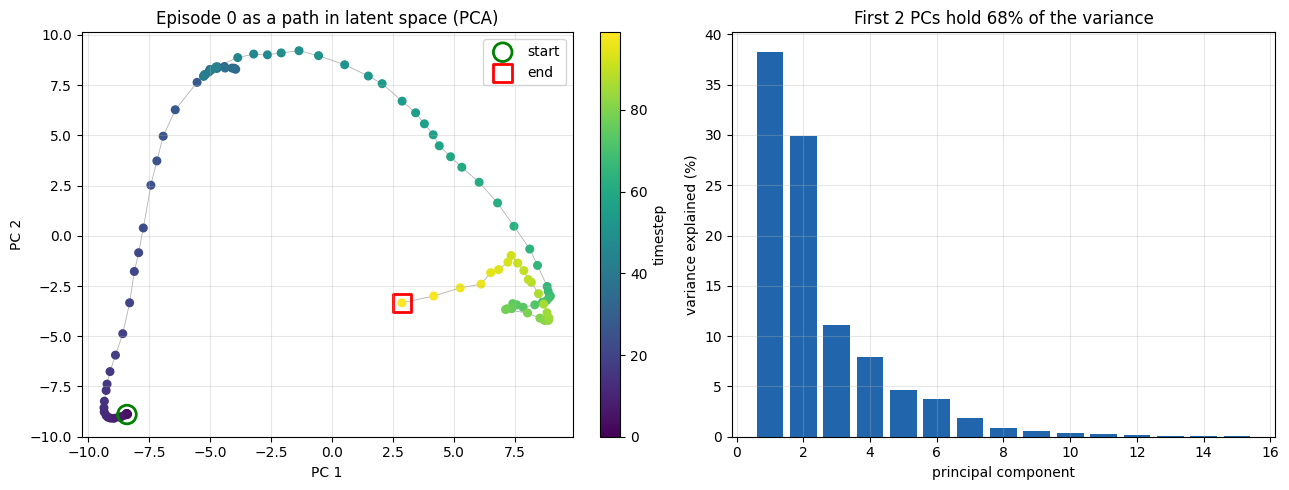

In [9]:
with h5py.File(H5, "r") as f:
    traj_px = f["pixels"][o : o + 100]

with torch.no_grad():
    traj = model.encode({"pixels": to_model_input(traj_px)})["emb"][0].cpu().numpy()

centred = traj - traj.mean(0)
U, S, Vt = np.linalg.svd(centred, full_matrices=False)
pcs = centred @ Vt[:2].T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sc = ax1.scatter(pcs[:, 0], pcs[:, 1], c=np.arange(len(pcs)), cmap="viridis", s=30)
ax1.plot(pcs[:, 0], pcs[:, 1], color="grey", lw=0.6, alpha=0.6, zorder=0)
ax1.scatter(*pcs[0], marker="o", s=180, facecolor="none", edgecolor="green", lw=2, label="start")
ax1.scatter(*pcs[-1], marker="s", s=180, facecolor="none", edgecolor="red", lw=2, label="end")
ax1.set_title("Episode 0 as a path in latent space (PCA)")
ax1.set_xlabel("PC 1"); ax1.set_ylabel("PC 2"); ax1.legend()
plt.colorbar(sc, ax=ax1, label="timestep", fraction=0.046)

var = (S ** 2) / (S ** 2).sum()
ax2.bar(range(1, 16), var[:15] * 100, color="#2166ac")
ax2.set_xlabel("principal component"); ax2.set_ylabel("variance explained (%)")
ax2.set_title(f"First 2 PCs hold {var[:2].sum()*100:.0f}% of the variance")
plt.tight_layout()
plt.show()

A smooth, continuous curve rather than a scatter of unrelated points. The
encoder has arranged time into geometry, without ever being told to.

## 4 · SIGReg, measured against the thing it is chasing

Notebook 00 showed `SIGReg` scoring synthetic inputs. Here it is applied to
**real embeddings**, alongside the actual distribution being tested.

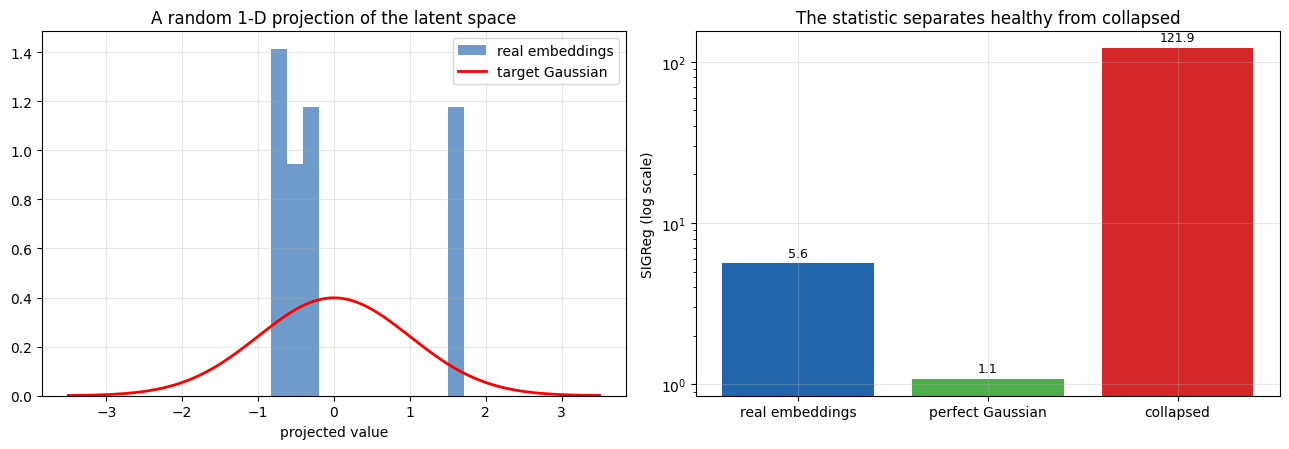

  real embeddings        5.63
  perfect Gaussian       1.08
  collapsed            121.88


In [10]:
sigreg = SIGReg(knots=17, num_proj=1024).to(DEVICE)

with h5py.File(H5, "r") as f:
    starts = [int(ep_offset[e]) for e in range(0, 400, 20)]
    big = np.stack([f["pixels"][s] for s in starts])       # (20, 224, 224, 3)

with torch.no_grad():
    real_emb = model.encode({"pixels": to_model_input(big)})["emb"][0]   # (20, D)

# Project real embeddings onto one random direction and compare to a Gaussian.
direction = torch.randn(real_emb.shape[-1], device=DEVICE)
direction /= direction.norm()
proj_real = (real_emb @ direction).cpu().numpy()
proj_real = (proj_real - proj_real.mean()) / (proj_real.std() + 1e-9)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

ax1.hist(proj_real, bins=12, density=True, alpha=0.65,
         color="#2166ac", label="real embeddings")
grid = np.linspace(-3.5, 3.5, 200)
ax1.plot(grid, np.exp(-grid**2/2)/math.sqrt(2*math.pi), "r-", lw=2, label="target Gaussian")
ax1.set_title("A random 1-D projection of the latent space")
ax1.set_xlabel("projected value"); ax1.legend()

# The statistic on real embeddings vs the two failure modes.
D = real_emb.shape[-1]
cases = {
    "real embeddings": real_emb.unsqueeze(0),
    "perfect Gaussian": torch.randn(1, 256, D, device=DEVICE),
    "collapsed": torch.zeros(1, 256, D, device=DEVICE) + 0.3,
}
names, vals = [], []
with torch.no_grad():
    for k, v in cases.items():
        names.append(k); vals.append(float(sigreg(v)))

bars = ax2.bar(names, vals, color=["#2166ac", "#4daf4a", "#d62728"])
ax2.set_yscale("log"); ax2.set_ylabel("SIGReg (log scale)")
ax2.set_title("The statistic separates healthy from collapsed")
for b, v in zip(bars, vals):
    ax2.text(b.get_x()+b.get_width()/2, v*1.1, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

for k, v in zip(names, vals):
    print(f"  {k:18s} {v:8.2f}")

The trained model's embeddings sit far closer to the Gaussian than to the
collapsed case. That is the regularizer having done its job during training.

## 5 · Training from scratch, live

Now the centrepiece. A **fresh, untrained** model, trained on real data, with
both losses and the embedding statistics recorded at every step.

The thing to watch is the embedding standard deviation. An untrained network
starts *almost perfectly collapsed* — every frame maps to nearly the same
vector. If SIGReg works, that number climbs to about 1.

### Caching, because random reads dominate

Sampling randomly from a 46 GB HDF5 costs ~1.4 s per batch and leaves the GPU
idle. Reading a few thousand sequences once, in sorted order, drops that to
~50 ms — a 26× speedup that turns this cell from IO-bound into compute-bound.

In [11]:
N_SEQ = 1536          # sequences to cache (~0.9 GB RAM)
BATCH = 32

rng = np.random.default_rng(0)
span = SEQ * FRAMESKIP

t0 = time.time()
with h5py.File(H5, "r") as f:
    lens, offs = f["ep_len"][:], f["ep_offset"][:]
    pixels, actions = f["pixels"], f["action"]

    # Choose (episode, start) pairs, then read in sorted order: HDF5 chunk
    # reads are much faster when the indices increase monotonically.
    picks = []
    while len(picks) < N_SEQ:
        ep = int(rng.integers(0, len(lens)))
        L = int(lens[ep])
        if L <= span + 1:
            continue
        picks.append(int(offs[ep]) + int(rng.integers(0, L - span - 1)))
    picks.sort()

    cache_px = np.empty((N_SEQ, SEQ, 224, 224, 3), np.uint8)
    cache_ac = np.empty((N_SEQ, SEQ, FRAMESKIP * 2), np.float32)
    for i, base in enumerate(picks):
        cache_px[i] = pixels[[base + j * FRAMESKIP for j in range(SEQ)]]
        # One model step = FRAMESKIP raw actions, flattened into a 10-vector.
        cache_ac[i] = np.stack([
            actions[base + j*FRAMESKIP : base + j*FRAMESKIP + FRAMESKIP].reshape(-1)
            for j in range(SEQ)
        ])

# NaNs appear at episode boundaries; train.py does the same nan_to_num.
cache_ac = np.nan_to_num(cache_ac, 0.0)
a_mean = cache_ac.reshape(-1, 10).mean(0)
a_std = cache_ac.reshape(-1, 10).std(0) + 1e-6
cache_ac = (cache_ac - a_mean) / a_std          # z-score, as  does

cache_px_t = torch.from_numpy(cache_px)
cache_ac_t = torch.from_numpy(cache_ac)

print(f"cached {N_SEQ} sequences of {SEQ} steps in {time.time()-t0:.0f}s "
      f"({cache_px.nbytes/1e9:.2f} GB RAM)")


def sample_batch(bs: int = BATCH) -> tuple[torch.Tensor, torch.Tensor]:
    """A random training batch from the cache, already on the GPU."""
    sel = torch.randint(0, N_SEQ, (bs,))
    px = cache_px_t[sel].to(DEVICE).permute(0, 1, 4, 2, 3).float() / 255.0
    px = (px - IMAGENET_MEAN.to(DEVICE)) / IMAGENET_STD.to(DEVICE)
    return px, cache_ac_t[sel].to(DEVICE)


px_b, ac_b = sample_batch()
print(f"batch: pixels {tuple(px_b.shape)}, actions {tuple(ac_b.shape)}")

cached 1536 sequences of 4 steps in 52s (0.92 GB RAM)
batch: pixels (32, 4, 3, 224, 224), actions (32, 4, 10)


### The training step

This is `lejepa_forward` from `train.py`, unrolled:

```
encode  ──▶ emb (B, T, D), act_emb (B, T, D)
predict ──▶ pred from the first HIST steps
             pred_loss   = MSE(pred, emb shifted by NPRED)
             sigreg_loss = SIGReg(emb)
             loss        = pred_loss + 0.09 * sigreg_loss
```

Two terms. That is the paper's claim — six hyperparameters reduced to one.

In [12]:
SIGREG_WEIGHT = 0.09      # the single loss hyperparameter, from lewm.yaml

# Training from scratch on the GPU. Flip RUN_TRAINING to True to run it for
# real; MINUTES sets the budget. With it False the rest of the notebook still
# runs end to end, so you can read through first and train when ready.
RUN_TRAINING = False
MINUTES = 5

fresh = build_model(cfg).to(DEVICE)      # random init: NOT the checkpoint
fresh.train()
sig_loss_fn = SIGReg(knots=17, num_proj=1024).to(DEVICE)
optimiser = torch.optim.AdamW(fresh.parameters(), lr=5e-5, weight_decay=1e-3)

# A fixed probe batch, so the "before" and "after" numbers are comparable.
probe_gen = torch.Generator().manual_seed(123)
probe_sel = torch.randint(0, N_SEQ, (64,), generator=probe_gen)
probe_px = cache_px_t[probe_sel].to(DEVICE).permute(0, 1, 4, 2, 3).float() / 255.0
probe_px = (probe_px - IMAGENET_MEAN.to(DEVICE)) / IMAGENET_STD.to(DEVICE)


def embedding_stats() -> float:
    """Per-dimension std of the probe embeddings. ~0 means collapsed."""
    fresh.eval()
    with torch.no_grad():
        e = fresh.encode({"pixels": probe_px})["emb"]
    fresh.train()
    return float(e.reshape(-1, e.shape[-1]).std(0).mean())


def train_step() -> tuple[float, float, float]:
    px, ac = sample_batch()
    out = fresh.encode({"pixels": px, "action": ac})
    emb, act_emb = out["emb"], out["act_emb"]

    pred = fresh.predict(emb[:, :HIST], act_emb[:, :HIST])   # prediction
    target = emb[:, NPRED:]                                  # ground truth

    pred_loss = (pred - target).pow(2).mean()
    sigreg_loss = sig_loss_fn(emb.transpose(0, 1))           # SIGReg wants (T, B, D)
    loss = pred_loss + SIGREG_WEIGHT * sigreg_loss

    optimiser.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(fresh.parameters(), 1.0)  # gradient_clip_val
    optimiser.step()
    return pred_loss.item(), sigreg_loss.item(), loss.item()


std_before = embedding_stats()
print(f"before training: embedding std = {std_before:.5f}")
print("  (essentially collapsed -- every frame maps to almost the same vector)")

history, std_after = None, None

if not RUN_TRAINING:
    print("\nRUN_TRAINING is False -- skipping the training loop.")
    print("Set it to True in the cell above and re-run to train for real.")
else:
    rows = []
    deadline = time.time() + MINUTES * 60
    step = 0
    print()
    while time.time() < deadline:
        pl, sl, tot = train_step()
        rows.append((step, pl, sl, tot))
        if step % 100 == 0:
            print(f"  step {step:4d}  pred {pl:.4f}  sigreg {sl:7.2f}  "
                  f"total {tot:.4f}  emb_std {embedding_stats():.4f}", flush=True)
        step += 1

    history = np.array(rows)
    std_after = embedding_stats()
    print(f"\n{step} steps in {MINUTES} minutes")
    print(f"embedding std: {std_before:.5f} -> {std_after:.4f}   "
          f"({std_after/max(std_before,1e-9):.0f}x)")

14:44:59 | INFO  | utils.py    | Created ViT-tiny from scratch with config: {'hidden_size': 192, 'num_hidden_layers': 12, 'num_attention_heads': 3, 'intermediate_size': 768, 'image_size': 224, 'patch_size': 14}
before training: embedding std = 0.00110
  (essentially collapsed -- every frame maps to almost the same vector)

RUN_TRAINING is False -- skipping the training loop.
Set it to True in the cell above and re-run to train for real.


### What the two losses did

In [13]:
def smooth(v: np.ndarray, k: int = 21) -> np.ndarray:
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")


if history is None:
    print("No training history yet -- set RUN_TRAINING = True above and re-run.")
else:
    steps, pred_l, sig_l, tot_l = history[:, 0], history[:, 1], history[:, 2], history[:, 3]
    off = len(steps) - len(smooth(pred_l))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

    axes[0].plot(steps, pred_l, alpha=0.25, color="#2166ac")
    axes[0].plot(steps[off:], smooth(pred_l), color="#2166ac", lw=2)
    axes[0].set_title("Prediction loss\n(is the world model learning dynamics?)")
    axes[0].set_xlabel("step"); axes[0].set_yscale("log")

    axes[1].plot(steps, sig_l, alpha=0.25, color="#d62728")
    axes[1].plot(steps[off:], smooth(sig_l), color="#d62728", lw=2)
    axes[1].set_title("SIGReg loss\n(are embeddings becoming Gaussian?)")
    axes[1].set_xlabel("step"); axes[1].set_yscale("log")

    axes[2].plot(steps, tot_l, alpha=0.25, color="#4daf4a")
    axes[2].plot(steps[off:], smooth(tot_l), color="#4daf4a", lw=2)
    axes[2].set_title(f"Total = pred + {SIGREG_WEIGHT} x sigreg")
    axes[2].set_xlabel("step"); axes[2].set_yscale("log")

    plt.tight_layout()
    plt.show()

    first, last = slice(0, 20), slice(-20, None)
    print(f"pred   loss: {pred_l[first].mean():.4f} -> {pred_l[last].mean():.4f} "
          f"({pred_l[first].mean()/pred_l[last].mean():.1f}x better)")
    print(f"sigreg loss: {sig_l[first].mean():7.2f} -> {sig_l[last].mean():.2f} "
          f"({sig_l[first].mean()/sig_l[last].mean():.1f}x better)")

No training history yet -- set RUN_TRAINING = True above and re-run.


### The escape from collapse

This is the figure that matters. A JEPA without a collapse-prevention mechanism
drives prediction loss to zero by making every embedding identical. Here,
prediction loss falls **and** the embeddings spread out — because SIGReg makes
the degenerate solution expensive.

In [14]:
if std_after is None:
    print("No 'after' measurement yet -- set RUN_TRAINING = True above and re-run.")
else:
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    bars = ax.bar(["before training", "after training"], [std_before, std_after],
                  color=["#d62728", "#4daf4a"], width=0.55)
    ax.axhline(1.0, ls="--", color="grey", lw=1.2)
    ax.text(1.42, 1.02, "target\n(unit variance)", fontsize=9, color="grey", va="bottom", ha="right")
    ax.set_ylabel("mean per-dimension std of embeddings")
    ax.set_title("SIGReg pulls the latent space out of collapse")
    for b, v in zip(bars, [std_before, std_after]):
        ax.text(b.get_x()+b.get_width()/2, v + 0.03, f"{v:.4f}", ha="center", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"A collapsed encoder has std ~0: every image maps to the same point.")
    print(f"This model went {std_before:.5f} -> {std_after:.4f} while ALSO")
    print(f"cutting prediction loss {pred_l[first].mean()/pred_l[last].mean():.1f}x.")
    print("\nWithout SIGReg, the easy way to cut prediction loss is to collapse.")
    print("That is the whole argument of the paper, visible in one run.")

No 'after' measurement yet -- set RUN_TRAINING = True above and re-run.


## 6 · Imagining the future

Back to the pretrained model. `rollout` encodes a few real frames, then feeds
the model its own predictions repeatedly — no further images.

Error should grow with horizon: small mistakes compound. Measuring that decay
is measuring how far ahead the model can usefully plan.

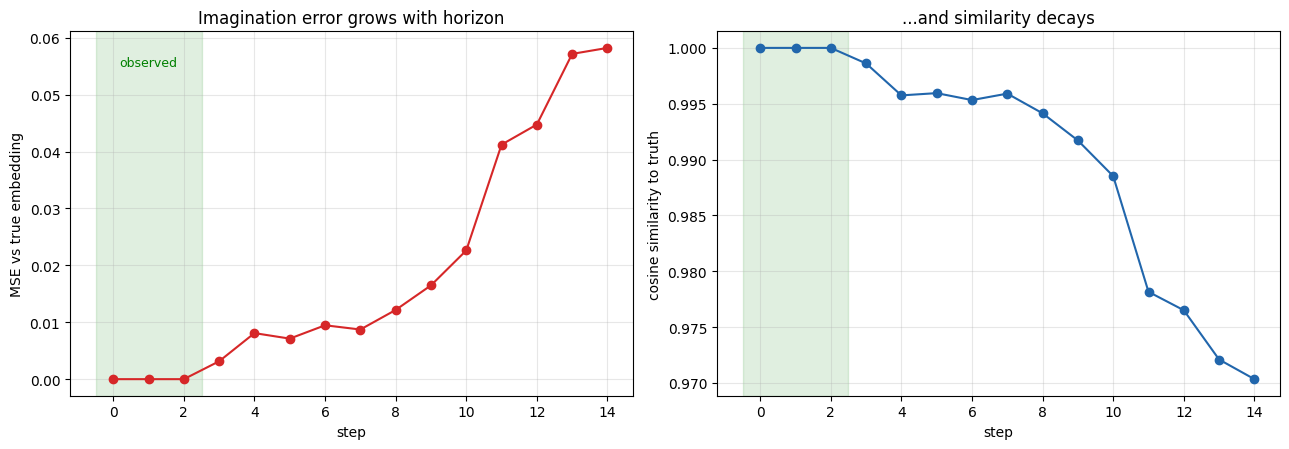

observed 3 frames, then imagined 12 steps blind
  error at first imagined step : 0.0031
  error at last imagined step  : 0.0582


In [15]:
HORIZON = 12
with h5py.File(H5, "r") as f:
    base = int(ep_offset[7])
    need = (HIST + HORIZON) * FRAMESKIP
    roll_px = f["pixels"][[base + i*FRAMESKIP for i in range(HIST + HORIZON)]]
    roll_ac = np.stack([
        f["action"][base + i*FRAMESKIP : base + i*FRAMESKIP + FRAMESKIP].reshape(-1)
        for i in range(HIST + HORIZON)
    ])
roll_ac = (np.nan_to_num(roll_ac, 0.0) - a_mean) / a_std

# Ground truth: encode every real frame.
with torch.no_grad():
    true_emb = model.encode({"pixels": to_model_input(roll_px)})["emb"][0]   # (HIST+HORIZON, D)

# Imagined: give the model only the first HIST frames, then the action plan.
info = {"pixels": to_model_input(roll_px[:HIST]).unsqueeze(1)}    # (1, 1, HIST, C, H, W)
plan = torch.as_tensor(roll_ac[:HIST + HORIZON]).float()[None, None].to(DEVICE)

with torch.no_grad():
    out = model.rollout(info, plan, history_size=HIST)
imagined = out["predicted_emb"][0, 0]       # (HIST+HORIZON+1, D)

n_cmp = min(len(true_emb), len(imagined))
err = (imagined[:n_cmp] - true_emb[:n_cmp]).pow(2).mean(-1).cpu().numpy()
cos = torch.nn.functional.cosine_similarity(imagined[:n_cmp], true_emb[:n_cmp], dim=-1).cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
ax1.plot(range(n_cmp), err, "o-", color="#d62728")
ax1.axvspan(-0.5, HIST - 0.5, color="green", alpha=0.12)
ax1.text(HIST/2 - 0.5, ax1.get_ylim()[1]*0.9, "observed", ha="center", fontsize=9, color="green")
ax1.set_xlabel("step"); ax1.set_ylabel("MSE vs true embedding")
ax1.set_title("Imagination error grows with horizon")

ax2.plot(range(n_cmp), cos, "o-", color="#2166ac")
ax2.axvspan(-0.5, HIST - 0.5, color="green", alpha=0.12)
ax2.set_xlabel("step"); ax2.set_ylabel("cosine similarity to truth")
ax2.set_title("...and similarity decays")
plt.tight_layout()
plt.show()

print(f"observed {HIST} frames, then imagined {n_cmp - HIST} steps blind")
print(f"  error at first imagined step : {err[HIST]:.4f}")
print(f"  error at last imagined step  : {err[-1]:.4f}")

### The frames it was imagining

The model never produces images — only embeddings. These are the real frames
corresponding to each imagined step, for intuition about what it was tracking.

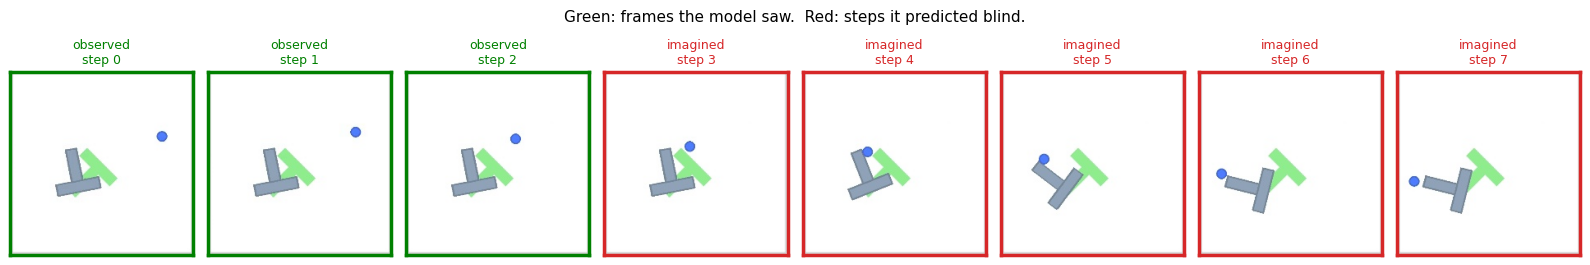

In [16]:
show = list(range(0, n_cmp, max(1, n_cmp // 8)))[:8]
fig, axes = plt.subplots(1, len(show), figsize=(2 * len(show), 2.9))
for ax, t in zip(axes, show):
    ax.imshow(roll_px[min(t, len(roll_px) - 1)])
    obs = t < HIST
    ax.set_title(("observed" if obs else "imagined") + f"\nstep {t}", fontsize=9,
                 color="green" if obs else "#d62728")
    for s in ax.spines.values():
        s.set_edgecolor("green" if obs else "#d62728"); s.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Green: frames the model saw.  Red: steps it predicted blind.", fontsize=11)
plt.tight_layout()
plt.show()

## 7 · Planning

Planning is the payoff. The model scores candidate action sequences by
imagining each one and measuring how close it lands to the goal.

`get_cost` does this for `S` candidates at once. The planner then keeps the
best — that is the entire algorithm.

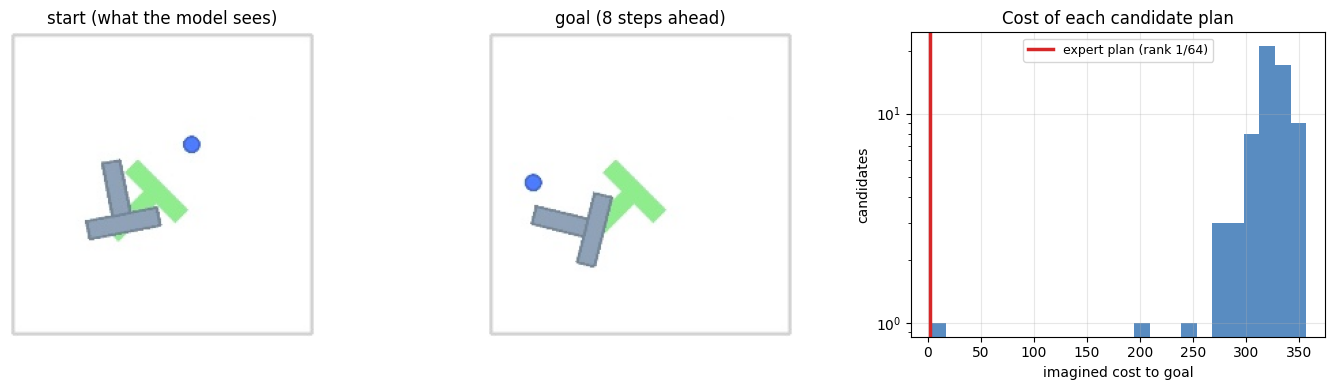

64 plans scored in one batched rollout
  expert plan :     2.21   <-- rank 1 of 64
  best random :   200.86
  worst       :   356.80

The expert's real actions score 91x lower than the best random plan.
The model has never seen these actions labelled as good -- it ranks them
first purely by imagining where they lead.


In [17]:
S = 64          # candidate plans
PLAN_H = 8      # steps per plan

with h5py.File(H5, "r") as f:
    start = int(ep_offset[3])
    # The goal is exactly PLAN_H steps ahead, so the expert's own actions can
    # actually reach it. (The next cell shows what happens when they cannot.)
    goal_i = start + PLAN_H * FRAMESKIP
    start_px = f["pixels"][[start + i*FRAMESKIP for i in range(HIST)]]
    goal_px = f["pixels"][goal_i]
    expert = np.stack([
        f["action"][start + i*FRAMESKIP : start + i*FRAMESKIP + FRAMESKIP].reshape(-1)
        for i in range(PLAN_H)
    ])
expert = (np.nan_to_num(expert, 0.0) - a_mean) / a_std


def score_plans(
    goal_image: np.ndarray, plans: torch.Tensor
) -> np.ndarray:
    """Cost of each candidate plan, all scored in one batched rollout."""
    n = plans.shape[0]
    info = {
        "pixels": to_model_input(start_px).unsqueeze(1).expand(1, n, HIST, 3, 224, 224).contiguous(),
        "goal": to_model_input(goal_image[None]).expand(1, n, HIST, 3, 224, 224).contiguous(),
        "action": plans[None].to(DEVICE),
    }
    with torch.no_grad():
        return model.get_cost(info, plans[None].to(DEVICE))[0].cpu().numpy()


# Candidates: the expert's real actions at index 0, plus S-1 random plans.
torch.manual_seed(0)
candidates = torch.randn(S, PLAN_H, 10) * 0.8
candidates[0] = torch.as_tensor(expert).float()

cost = score_plans(goal_px, candidates)
rank = int(np.where(np.argsort(cost) == 0)[0][0])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
ax1.imshow(start_px[-1]); ax1.set_title("start (what the model sees)"); ax1.axis("off")
ax2.imshow(goal_px); ax2.set_title(f"goal ({PLAN_H} steps ahead)"); ax2.axis("off")

ax3.hist(cost, bins=24, color="#2166ac", alpha=0.75)
ax3.axvline(cost[0], color="#d62728", lw=2.5, label=f"expert plan (rank {rank+1}/{S})")
ax3.set_xlabel("imagined cost to goal"); ax3.set_ylabel("candidates")
ax3.set_title("Cost of each candidate plan"); ax3.legend(fontsize=9)
ax3.set_yscale("log")
plt.tight_layout()
plt.show()

print(f"{S} plans scored in one batched rollout")
print(f"  expert plan : {cost[0]:8.2f}   <-- rank {rank+1} of {S}")
print(f"  best random : {cost[1:].min():8.2f}")
print(f"  worst       : {cost.max():8.2f}")
print(f"\nThe expert's real actions score {cost[1:].min()/max(cost[0],1e-9):.0f}x lower "
      f"than the best random plan.")
print("The model has never seen these actions labelled as good -- it ranks them")
print("first purely by imagining where they lead.")

### The cost only means something if the goal is reachable

Above, the goal sat exactly `PLAN_H` steps ahead, so the expert's actions could
actually arrive. Move the goal twice as far while keeping the plan the same
length and the ranking falls apart — not because the model is wrong, but
because *no* 8-step plan can reach a 16-step-away goal.

This is a real property of planning with a fixed horizon, and worth seeing
before you trust a cost number.

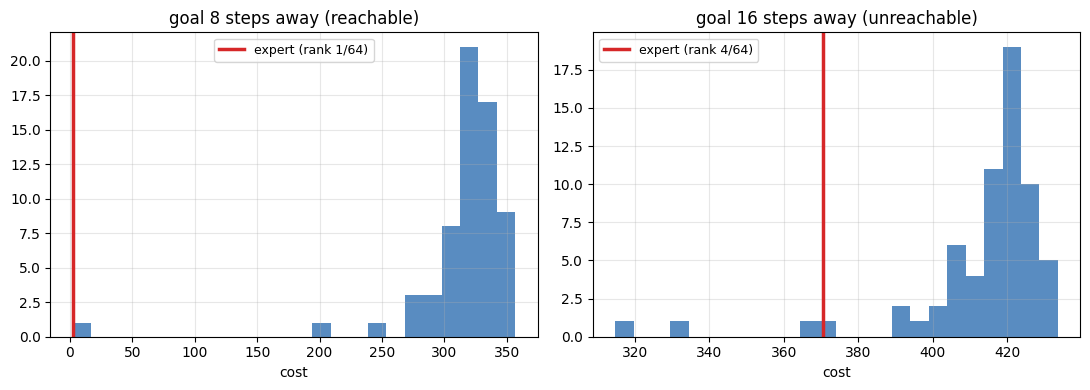

reachable goal   : expert rank 1/64, cost 2.2
unreachable goal : expert rank 4/64, cost 370.5

With the goal out of reach every plan is bad, and the ordering among
them is mostly noise. Horizon has to match the distance to the goal.


In [18]:
with h5py.File(H5, "r") as f:
    far_goal = f["pixels"][start + PLAN_H * FRAMESKIP * 2]      # twice as far

cost_far = score_plans(far_goal, candidates)
rank_far = int(np.where(np.argsort(cost_far) == 0)[0][0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ax, (c, r, title) in zip(
    (ax1, ax2),
    [(cost, rank, f"goal {PLAN_H} steps away (reachable)"),
     (cost_far, rank_far, f"goal {PLAN_H*2} steps away (unreachable)")],
):
    ax.hist(c, bins=24, color="#2166ac", alpha=0.75)
    ax.axvline(c[0], color="#d62728", lw=2.5, label=f"expert (rank {r+1}/{S})")
    ax.set_title(title); ax.set_xlabel("cost"); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"reachable goal   : expert rank {rank+1}/{S}, cost {cost[0]:.1f}")
print(f"unreachable goal : expert rank {rank_far+1}/{S}, cost {cost_far[0]:.1f}")
print("\nWith the goal out of reach every plan is bad, and the ordering among")
print("them is mostly noise. Horizon has to match the distance to the goal.")

## Where to go next

| Want to... | Do this |
|:---|:---|
| Train properly | `uv run python train.py data=pusht` (100 epochs, hours) |
| Evaluate with planning | `uv run python eval.py --config-name=pusht.yaml policy=pusht/lewm` |
| Change the architecture | edit `nbs/00_module.ipynb`, run `uv run nbdev-export` |
| Change the model | edit `nbs/01_jepa.ipynb`, run `uv run nbdev-export` |

### The three ideas worth keeping

1. **Predict embeddings, not pixels.** The model chooses what to represent, so
   it can discard everything irrelevant to control.
2. **Collapse is the central difficulty.** Predicting your own output is
   trivially solved by outputting a constant.
3. **One regularizer is enough.** Forcing embeddings to be Gaussian makes
   collapse impossible, with no stop-gradient, momentum encoder or auxiliary
   loss — which is what section 5 showed happening live.